In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import data

In [2]:
orders=pd.read_csv(r"D:\Data Analyst\EXCEL\supplychain\FACT_ORDERS.csv")
orders.head()

,order_line_id,order_id,date_id,order_date,customer_id,product_id,category,seller_id,seller_rating,location_id,...,return_date,customer_rating,review_text,sentiment_score,delivery_delay_days,delivery_sla_days,gross_amount,discount_amount,tax_amount,net_amount
0,OL00000001,ORD0210788,2026-02-20,2026-02-20,CUST009513,PROD000763,Baby,SELL2379,4.6,LOC0010,...,NaN,4.4,Very soft and baby-friendly material.,0.84,0,2,39998,3863.8068,1999.90,38220.7332
1,OL00000002,ORD0248321,2025-12-02,2025-12-02,CUST003412,PROD000142,Clothing,SELL2964,4.0,LOC0053,...,NaN,4.3,Stitching is neat and well-finished.,0.66,1,1,9996,703.7184,499.80,10007.8716
2,OL00000003,ORD0377603,2025-04-03,2025-04-03,CUST065509,PROD001194,Gaming,SELL2485,3.9,LOC0095,...,NaN,4.6,Highly enjoyable and worth it.,0.44,1,2,449995,25874.7125,22499.75,446706.6775
3,OL00000004,ORD0019414,2025-06-01,2025-06-01,CUST070677,PROD000221,Home,SELL4121,4.0,LOC0038,...,NaN,4.6,Fits perfectly in my space.,0.28,0,2,4497,27.4317,224.85,4781.0583
4,OL00000005,ORD0157859,2025-10-25,2025-10-25,CUST017845,PROD000806,Pets,SELL3183,4.5,LOC0109,...,NaN,4.0,Strong and long-lasting material.,0.35,0,1,598,26.3718,29.90,817.3182


copy the original data

In [3]:
df=orders.copy()

check all columns in the table

In [4]:
df.columns

Index(['order_line_id', 'order_id', 'date_id', 'order_date', 'customer_id',
       'product_id', 'category', 'seller_id', 'seller_rating', 'location_id',
       'delivery_person_id', 'payment_id', 'campaign_id', 'fulfillment_id',
       'quantity', 'unit_price', 'discount_percentage', 'tax_percentage',
       'shipping_fee', 'expected_delivery_date', 'actual_delivery_date',
       'delivery_rating', 'order_status', 'return_flag', 'refund_amount',
       'return_date', 'customer_rating', 'review_text', 'sentiment_score',
       'delivery_delay_days', 'delivery_sla_days', 'gross_amount',
       'discount_amount', 'tax_amount', 'net_amount'],
      dtype='object')

Check info of the table like column_name and data_types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790732 entries, 0 to 790731
Data columns (total 35 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_line_id           790732 non-null  object 
 1   order_id                790732 non-null  object 
 2   date_id                 790732 non-null  object 
 3   order_date              790732 non-null  object 
 4   customer_id             790732 non-null  object 
 5   product_id              790732 non-null  object 
 6   category                790732 non-null  object 
 7   seller_id               790732 non-null  object 
 8   seller_rating           751390 non-null  float64
 9   location_id             790732 non-null  object 
 10  delivery_person_id      790732 non-null  object 
 11  payment_id              790732 non-null  object 
 12  campaign_id             790732 non-null  object 
 13  fulfillment_id          790732 non-null  object 
 14  quantity            

describe the data to indentify outliers and how the data spread

In [6]:
df.describe()

,seller_rating,quantity,unit_price,discount_percentage,tax_percentage,shipping_fee,delivery_rating,refund_amount,customer_rating,sentiment_score,delivery_delay_days,delivery_sla_days,gross_amount,discount_amount,tax_amount,net_amount
count,751390.000000,790732.000000,7.907320e+05,790732.000000,790732.0,790732.000000,751390.000000,790732.000000,751390.000000,790732.000000,790732.000000,790732.000000,7.907320e+05,790732.000000,790732.000000,7.907320e+05
mean,3.934732,3.001877,1.443109e+04,4.998254,5.0,116.332926,3.999883,-15.148007,3.718927,0.379188,0.450298,2.663600,4.322148e+04,2156.610857,2161.074214,4.334228e+04
std,0.911800,1.413882,5.030919e+04,2.886348,0.0,72.308419,0.857078,47.047367,0.910232,0.455638,0.668581,1.698761,1.670267e+05,9589.267398,8351.335561,1.672835e+05
min,1.000000,1.000000,2.000000e+01,0.000000,5.0,46.270000,1.000000,-215.790000,1.000000,-1.000000,0.000000,1.000000,2.000000e+01,0.000000,1.000000,6.536000e+01
25%,3.700000,2.000000,6.990000e+02,2.500000,5.0,46.270000,3.600000,0.000000,3.300000,0.180000,0.000000,1.000000,1.598000e+03,56.780100,79.900000,1.743271e+03
50%,4.100000,3.000000,1.999000e+03,4.990000,5.0,86.640000,4.200000,0.000000,3.800000,0.450000,0.000000,2.000000,5.397000e+03,220.310400,269.850000,5.480861e+03
75%,4.600000,4.000000,8.499000e+03,7.500000,5.0,215.790000,4.600000,0.000000,4.400000,0.730000,1.000000,5.000000,2.249500e+04,974.610000,1124.750000,2.240403e+04
max,5.000000,5.000000,1.150000e+06,10.000000,5.0,215.790000,5.000000,0.000000,5.000000,1.000000,2.000000,5.000000,5.750000e+06,572700.000000,287500.000000,6.031796e+06


Remove the unwanted columns

In [7]:
df=df[['order_line_id', 'order_date', 'customer_id',
       'product_id', 'category', 'seller_id', 'seller_rating', 'location_id',
       'delivery_person_id', 'payment_id', 'campaign_id', 'fulfillment_id',
       'quantity', 'unit_price', 'discount_percentage', 'tax_percentage',
       'shipping_fee', 'actual_delivery_date',
       'delivery_rating', 'order_status', 'return_flag', 'refund_amount',
       'return_date', 'customer_rating', 'review_text', 'sentiment_score',
       'delivery_delay_days', 'gross_amount',
       'discount_amount', 'tax_amount', 'net_amount']]

In [8]:
df.head()

,order_line_id,order_date,customer_id,product_id,category,seller_id,seller_rating,location_id,delivery_person_id,payment_id,...,refund_amount,return_date,customer_rating,review_text,sentiment_score,delivery_delay_days,gross_amount,discount_amount,tax_amount,net_amount
0,OL00000001,2026-02-20,CUST009513,PROD000763,Baby,SELL2379,4.6,LOC0010,DEL01094,PAY005,...,0.0,NaN,4.4,Very soft and baby-friendly material.,0.84,0,39998,3863.8068,1999.90,38220.7332
1,OL00000002,2025-12-02,CUST003412,PROD000142,Clothing,SELL2964,4.0,LOC0053,DEL01927,PAY004,...,0.0,NaN,4.3,Stitching is neat and well-finished.,0.66,1,9996,703.7184,499.80,10007.8716
2,OL00000003,2025-04-03,CUST065509,PROD001194,Gaming,SELL2485,3.9,LOC0095,DEL00300,PAY009,...,0.0,NaN,4.6,Highly enjoyable and worth it.,0.44,1,449995,25874.7125,22499.75,446706.6775
3,OL00000004,2025-06-01,CUST070677,PROD000221,Home,SELL4121,4.0,LOC0038,DEL02152,PAY004,...,0.0,NaN,4.6,Fits perfectly in my space.,0.28,0,4497,27.4317,224.85,4781.0583
4,OL00000005,2025-10-25,CUST017845,PROD000806,Pets,SELL3183,4.5,LOC0109,DEL03896,PAY012,...,0.0,NaN,4.0,Strong and long-lasting material.,0.35,0,598,26.3718,29.90,817.3182


Find the null or missing values in the data

In [9]:
df.isna().sum()

order_line_id                0
order_date                   0
customer_id                  0
product_id                   0
category                     0
seller_id                    0
seller_rating            39342
location_id                  0
delivery_person_id           0
payment_id                   0
campaign_id                  0
fulfillment_id               0
quantity                     0
unit_price                   0
discount_percentage          0
tax_percentage               0
shipping_fee                 0
actual_delivery_date         0
delivery_rating          39342
order_status                 0
return_flag                  0
refund_amount                0
return_date             687697
customer_rating          39342
review_text              39342
sentiment_score              0
delivery_delay_days          0
gross_amount                 0
discount_amount              0
tax_amount                   0
net_amount                   0
dtype: int64

Handling Missing values in columns

In [10]:
missing_values=df[['seller_rating','return_date','delivery_rating','customer_rating','review_text']]

Missing values describtion to find the how the data is spread

In [11]:
missing_values.describe()

,seller_rating,delivery_rating,customer_rating
count,751390.000000,751390.000000,751390.000000
mean,3.934732,3.999883,3.718927
std,0.911800,0.857078,0.910232
min,1.000000,1.000000,1.000000
25%,3.700000,3.600000,3.300000
50%,4.100000,4.200000,3.800000
75%,4.600000,4.600000,4.400000
max,5.000000,5.000000,5.000000


Check the seller_rating to find outliers

<Axes: ylabel='seller_rating'>

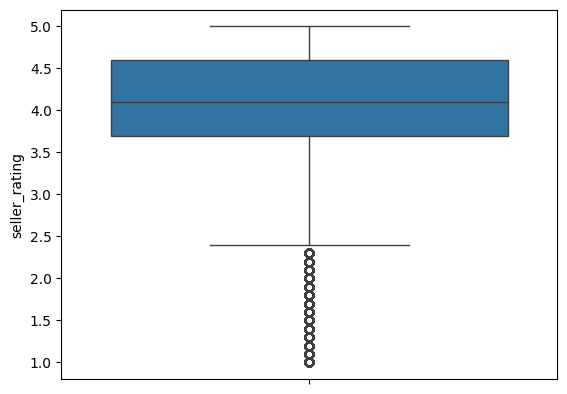

In [12]:
#seller_rating

sns.boxplot(data=df,y='seller_rating')

fill null ond missing values of seller_rating with mean

In [13]:
# filling seller_rating with mean
df['seller_rating']=df['seller_rating'].fillna(df['seller_rating'].mean())

Check the delivery_rating to find outliers

<Axes: ylabel='delivery_rating'>

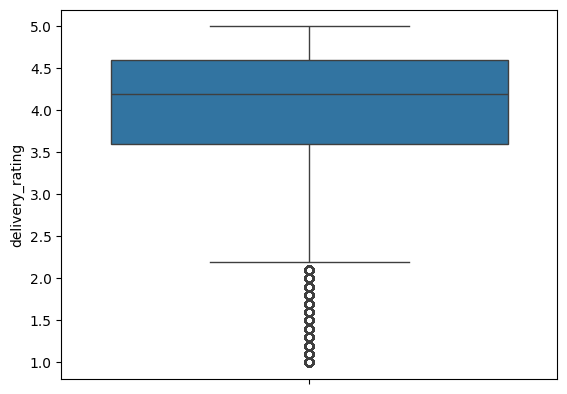

In [14]:
#delivery_rating

sns.boxplot(data=df,y='delivery_rating')

fill null ond missing values of seller_rating with mean

In [15]:
# filling delivery_rating with mean
df['delivery_rating']=df['delivery_rating'].fillna(df['delivery_rating'].mean())

Check the customer_rating to find outliers

<Axes: ylabel='customer_rating'>

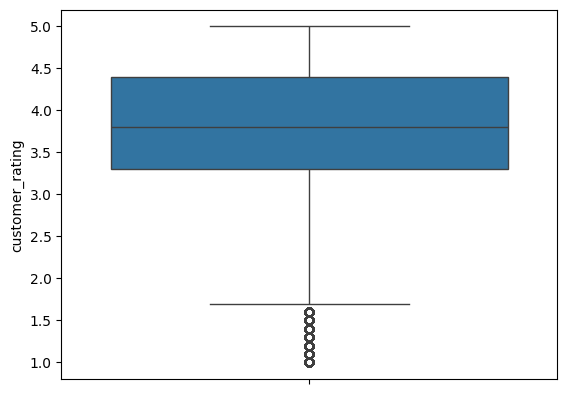

In [16]:
#customer_rating

sns.boxplot(data=df,y='customer_rating')

fill null ond missing values of seller_rating with mean

In [17]:
# filling customer_rating with mean
df['customer_rating']=df['customer_rating'].fillna(df['customer_rating'].mean())

In [18]:
df.isna().sum()

order_line_id                0
order_date                   0
customer_id                  0
product_id                   0
category                     0
seller_id                    0
seller_rating                0
location_id                  0
delivery_person_id           0
payment_id                   0
campaign_id                  0
fulfillment_id               0
quantity                     0
unit_price                   0
discount_percentage          0
tax_percentage               0
shipping_fee                 0
actual_delivery_date         0
delivery_rating              0
order_status                 0
return_flag                  0
refund_amount                0
return_date             687697
customer_rating              0
review_text              39342
sentiment_score              0
delivery_delay_days          0
gross_amount                 0
discount_amount              0
tax_amount                   0
net_amount                   0
dtype: int64

correcting the data type of return date

In [19]:
df['return_date']=pd.to_datetime(df['return_date'])

In [20]:
df['return_date'].isnull().sum()

np.int64(687697)

In [21]:
df.isna().sum()

order_line_id                0
order_date                   0
customer_id                  0
product_id                   0
category                     0
seller_id                    0
seller_rating                0
location_id                  0
delivery_person_id           0
payment_id                   0
campaign_id                  0
fulfillment_id               0
quantity                     0
unit_price                   0
discount_percentage          0
tax_percentage               0
shipping_fee                 0
actual_delivery_date         0
delivery_rating              0
order_status                 0
return_flag                  0
refund_amount                0
return_date             687697
customer_rating              0
review_text              39342
sentiment_score              0
delivery_delay_days          0
gross_amount                 0
discount_amount              0
tax_amount                   0
net_amount                   0
dtype: int64

fill null ond missing values of return_date with 0 because the order not been return so the return date will be 0

In [22]:
df['return_date']=df['return_date'].fillna(0)

In [23]:
df.isna().sum()

order_line_id               0
order_date                  0
customer_id                 0
product_id                  0
category                    0
seller_id                   0
seller_rating               0
location_id                 0
delivery_person_id          0
payment_id                  0
campaign_id                 0
fulfillment_id              0
quantity                    0
unit_price                  0
discount_percentage         0
tax_percentage              0
shipping_fee                0
actual_delivery_date        0
delivery_rating             0
order_status                0
return_flag                 0
refund_amount               0
return_date                 0
customer_rating             0
review_text             39342
sentiment_score             0
delivery_delay_days         0
gross_amount                0
discount_amount             0
tax_amount                  0
net_amount                  0
dtype: int64

if the customer not give comment it will be null so fill with no comments

In [24]:
df['review_text']=df['review_text'].fillna("no comments")

In [25]:
df.isna().sum()

order_line_id           0
order_date              0
customer_id             0
product_id              0
category                0
seller_id               0
seller_rating           0
location_id             0
delivery_person_id      0
payment_id              0
campaign_id             0
fulfillment_id          0
quantity                0
unit_price              0
discount_percentage     0
tax_percentage          0
shipping_fee            0
actual_delivery_date    0
delivery_rating         0
order_status            0
return_flag             0
refund_amount           0
return_date             0
customer_rating         0
review_text             0
sentiment_score         0
delivery_delay_days     0
gross_amount            0
discount_amount         0
tax_amount              0
net_amount              0
dtype: int64

correcting the data_type of order_date

In [26]:
df['order_date']=pd.to_datetime(df['order_date'])

check duplicate_values

In [27]:
df.duplicated().sum()

np.int64(0)

drop duplicated_values

In [28]:
df.drop_duplicates()

,order_line_id,order_date,customer_id,product_id,category,seller_id,seller_rating,location_id,delivery_person_id,payment_id,...,refund_amount,return_date,customer_rating,review_text,sentiment_score,delivery_delay_days,gross_amount,discount_amount,tax_amount,net_amount
0,OL00000001,2026-02-20,CUST009513,PROD000763,Baby,SELL2379,4.6,LOC0010,DEL01094,PAY005,...,0.00,0,4.4,Very soft and baby-friendly material.,0.84,0,39998,3863.8068,1999.90,38220.7332
1,OL00000002,2025-12-02,CUST003412,PROD000142,Clothing,SELL2964,4.0,LOC0053,DEL01927,PAY004,...,0.00,0,4.3,Stitching is neat and well-finished.,0.66,1,9996,703.7184,499.80,10007.8716
2,OL00000003,2025-04-03,CUST065509,PROD001194,Gaming,SELL2485,3.9,LOC0095,DEL00300,PAY009,...,0.00,0,4.6,Highly enjoyable and worth it.,0.44,1,449995,25874.7125,22499.75,446706.6775
3,OL00000004,2025-06-01,CUST070677,PROD000221,Home,SELL4121,4.0,LOC0038,DEL02152,PAY004,...,0.00,0,4.6,Fits perfectly in my space.,0.28,0,4497,27.4317,224.85,4781.0583
4,OL00000005,2025-10-25,CUST017845,PROD000806,Pets,SELL3183,4.5,LOC0109,DEL03896,PAY012,...,0.00,0,4.0,Strong and long-lasting material.,0.35,0,598,26.3718,29.90,817.3182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790727,OL00790728,2025-11-15,CUST073518,PROD001236,Office Supplies,SELL3351,3.7,LOC0093,DEL06036,PAY008,...,0.00,0,4.8,Good quality and long-lasting.,0.39,0,59996,1697.8868,2999.80,61513.7032
790728,OL00790729,2025-09-02,CUST027946,PROD000245,Home,SELL0889,4.4,LOC0066,DEL00856,PAY002,...,0.00,0,3.8,Sturdy build and easy to assemble.,0.89,1,59996,3359.7760,2999.80,59851.8140
790729,OL00790730,2026-02-07,CUST003703,PROD001217,Office Supplies,SELL1882,2.3,LOC0095,DEL05064,PAY014,...,-86.64,2026-02-11 00:00:00,2.3,Missing parts,-0.21,0,44995,638.9290,2249.75,46692.4610
790730,OL00790731,2025-04-03,CUST004618,PROD000427,Sports,SELL3383,3.6,LOC0066,DEL06494,PAY012,...,0.00,0,4.3,Comfortable and enhances performance.,0.23,0,9996,118.9524,499.80,10423.1176


rounded the values in the table

In [29]:
df['discount_amount']=round(df['discount_amount'],2)

In [30]:
df['net_amount']=round(df['net_amount'],2)

In [31]:
df.head()

,order_line_id,order_date,customer_id,product_id,category,seller_id,seller_rating,location_id,delivery_person_id,payment_id,...,refund_amount,return_date,customer_rating,review_text,sentiment_score,delivery_delay_days,gross_amount,discount_amount,tax_amount,net_amount
0,OL00000001,2026-02-20,CUST009513,PROD000763,Baby,SELL2379,4.6,LOC0010,DEL01094,PAY005,...,0.0,0,4.4,Very soft and baby-friendly material.,0.84,0,39998,3863.81,1999.90,38220.73
1,OL00000002,2025-12-02,CUST003412,PROD000142,Clothing,SELL2964,4.0,LOC0053,DEL01927,PAY004,...,0.0,0,4.3,Stitching is neat and well-finished.,0.66,1,9996,703.72,499.80,10007.87
2,OL00000003,2025-04-03,CUST065509,PROD001194,Gaming,SELL2485,3.9,LOC0095,DEL00300,PAY009,...,0.0,0,4.6,Highly enjoyable and worth it.,0.44,1,449995,25874.71,22499.75,446706.68
3,OL00000004,2025-06-01,CUST070677,PROD000221,Home,SELL4121,4.0,LOC0038,DEL02152,PAY004,...,0.0,0,4.6,Fits perfectly in my space.,0.28,0,4497,27.43,224.85,4781.06
4,OL00000005,2025-10-25,CUST017845,PROD000806,Pets,SELL3183,4.5,LOC0109,DEL03896,PAY012,...,0.0,0,4.0,Strong and long-lasting material.,0.35,0,598,26.37,29.90,817.32


EDA(exploratory data analysis)

unilateral analysis

Finding outliers each column

<Axes: ylabel='order_date'>

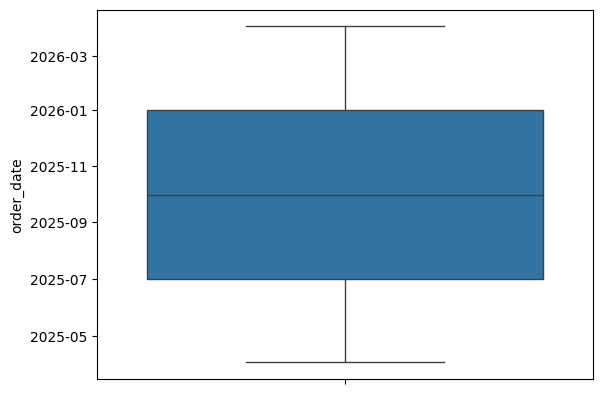

In [47]:
#find the outliers in the order_date how the date is spread
sns.boxplot(data=df,y='order_date')

<Axes: xlabel='quantity'>

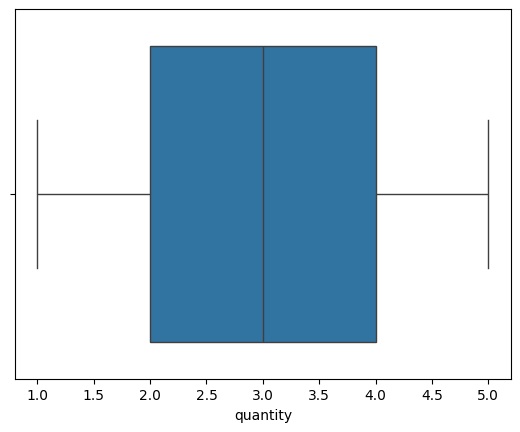

In [48]:
#Find the quantity 
sns.boxplot(data=df,x='quantity')

<Axes: xlabel='unit_price'>

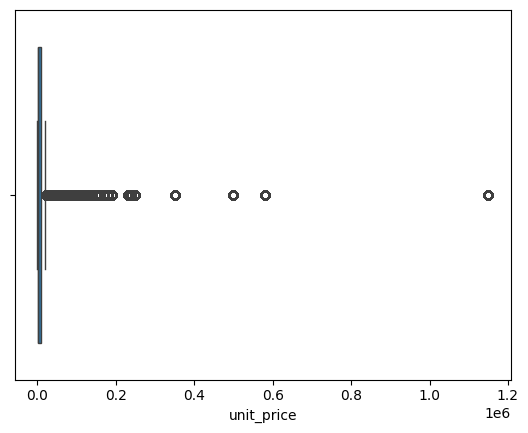

In [52]:
#Find the unit_price
sns.boxplot(data=df,x='unit_price')

In [ ]:
#in the above plot the point is for away from the data so we think as outlier but is real data because it is one product 


df[df['unit_price']==1150000][['product_id']].drop_duplicates()

,product_id
871,PROD000971


<Axes: xlabel='discount_percentage'>

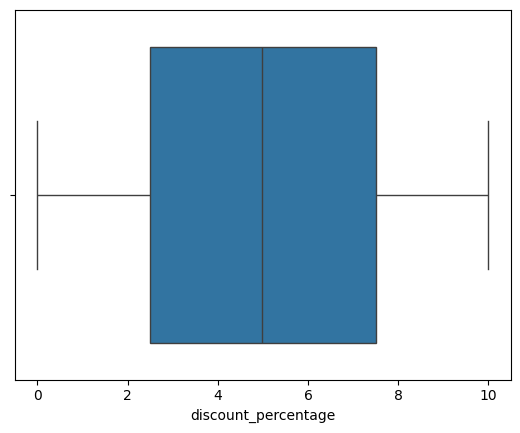

In [ ]:
#Find the discount_percentage
sns.boxplot(data=df,x='discount_percentage')

<Axes: xlabel='tax_percentage'>

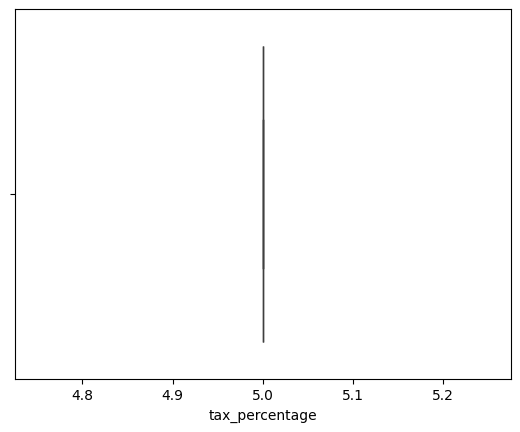

In [65]:
#Find the tax_percentage
sns.boxplot(data=df,x='tax_percentage')

<Axes: xlabel='shipping_fee'>

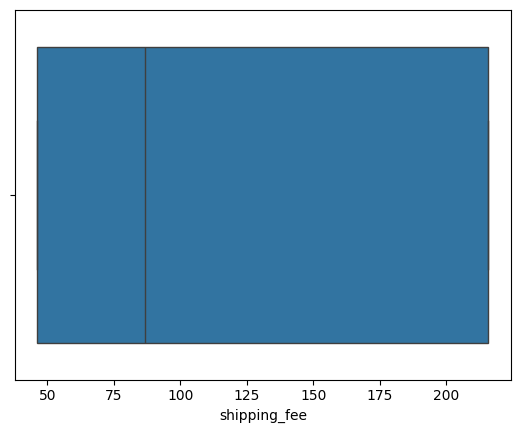

In [67]:
#Find the quantity 
sns.boxplot(data=df,x='shipping_fee')

<Axes: xlabel='refund_amount'>

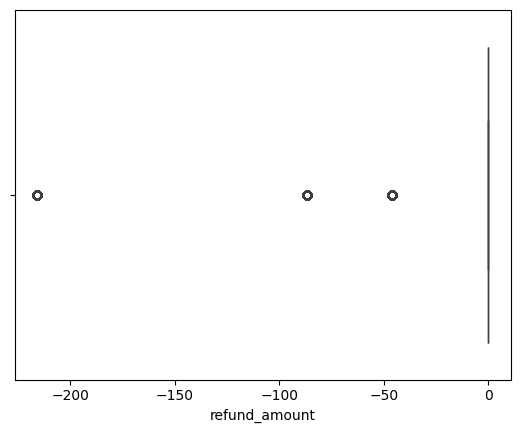

In [69]:
#Find the quantity 
sns.boxplot(data=df,x='refund_amount')

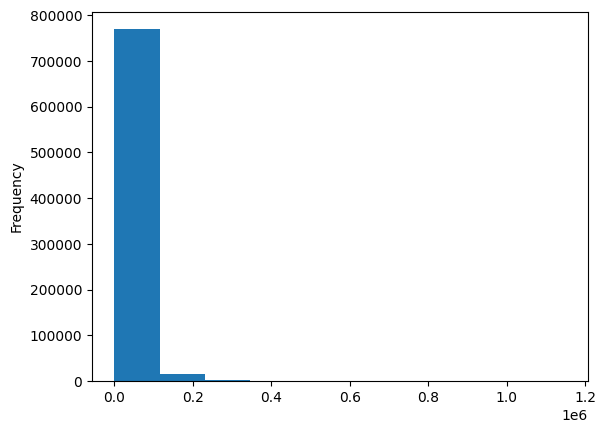

In [70]:
df.unit_price.plot.hist()
plt.show()

In [72]:
df1=df.copy()

In [66]:
df.head()

,order_line_id,order_date,customer_id,product_id,category,seller_id,seller_rating,location_id,delivery_person_id,payment_id,...,refund_amount,return_date,customer_rating,review_text,sentiment_score,delivery_delay_days,gross_amount,discount_amount,tax_amount,net_amount
0,OL00000001,2026-02-20,CUST009513,PROD000763,Baby,SELL2379,4.6,LOC0010,DEL01094,PAY005,...,0.0,0,4.4,Very soft and baby-friendly material.,0.84,0,39998,3863.81,1999.90,38220.73
1,OL00000002,2025-12-02,CUST003412,PROD000142,Clothing,SELL2964,4.0,LOC0053,DEL01927,PAY004,...,0.0,0,4.3,Stitching is neat and well-finished.,0.66,1,9996,703.72,499.80,10007.87
2,OL00000003,2025-04-03,CUST065509,PROD001194,Gaming,SELL2485,3.9,LOC0095,DEL00300,PAY009,...,0.0,0,4.6,Highly enjoyable and worth it.,0.44,1,449995,25874.71,22499.75,446706.68
3,OL00000004,2025-06-01,CUST070677,PROD000221,Home,SELL4121,4.0,LOC0038,DEL02152,PAY004,...,0.0,0,4.6,Fits perfectly in my space.,0.28,0,4497,27.43,224.85,4781.06
4,OL00000005,2025-10-25,CUST017845,PROD000806,Pets,SELL3183,4.5,LOC0109,DEL03896,PAY012,...,0.0,0,4.0,Strong and long-lasting material.,0.35,0,598,26.37,29.90,817.32


In [109]:
df.columns

Index(['order_line_id', 'order_date', 'customer_id', 'product_id', 'category',
       'seller_id', 'seller_rating', 'location_id', 'delivery_person_id',
       'payment_id', 'campaign_id', 'fulfillment_id', 'quantity', 'unit_price',
       'discount_percentage', 'tax_percentage', 'shipping_fee',
       'actual_delivery_date', 'delivery_rating', 'order_status',
       'return_flag', 'refund_amount', 'return_date', 'customer_rating',
       'review_text', 'sentiment_score', 'delivery_delay_days', 'gross_amount',
       'discount_amount', 'tax_amount', 'net_amount'],
      dtype='object')

In [105]:
df1=df[['quantity', 'unit_price',
       'discount_percentage', 'tax_percentage', 'shipping_fee', 'delivery_rating', 'customer_rating','sentiment_score', 'gross_amount',
       'discount_amount', 'tax_amount', 'net_amount']]

In [104]:
df1.head()

,quantity,unit_price,discount_percentage,tax_percentage,shipping_fee,delivery_rating,return_date,customer_rating,sentiment_score,gross_amount,discount_amount,tax_amount,net_amount
0,2,19999,9.66,5.0,86.64,4.5,0,4.4,0.84,39998,3863.81,1999.90,38220.73
1,4,2499,7.04,5.0,215.79,3.9,0,4.3,0.66,9996,703.72,499.80,10007.87
2,5,89999,5.75,5.0,86.64,3.9,0,4.6,0.44,449995,25874.71,22499.75,446706.68
3,3,1499,0.61,5.0,86.64,4.0,0,4.6,0.28,4497,27.43,224.85,4781.06
4,2,299,4.41,5.0,215.79,5.0,0,4.0,0.35,598,26.37,29.90,817.32


In [106]:
df1.mean()

quantity                   3.001877
unit_price             14431.086297
discount_percentage        4.998254
tax_percentage             5.000000
shipping_fee             116.332926
delivery_rating            3.999883
customer_rating            3.718927
sentiment_score            0.379188
gross_amount           43221.484288
discount_amount         2156.610854
tax_amount              2161.074214
net_amount             43342.280581
dtype: float64

In [108]:
corr=df1.corr()
corr

,quantity,unit_price,discount_percentage,tax_percentage,shipping_fee,delivery_rating,customer_rating,sentiment_score,gross_amount,discount_amount,tax_amount,net_amount
quantity,1.000000,-0.001390,0.001006,NaN,0.000394,-0.001685,0.001707,0.000385,0.121011,0.104855,0.121011,0.120856
unit_price,-0.001390,1.000000,-0.000479,NaN,-0.001671,-0.000564,-0.001276,-0.000228,0.895692,0.766105,0.895692,0.895116
discount_percentage,0.001006,-0.000479,1.000000,NaN,-0.000285,0.000526,-0.000707,-0.001423,-0.000769,0.130004,-0.000769,-0.008259
tax_percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_fee,0.000394,-0.001671,-0.000285,NaN,1.000000,-0.002122,0.000318,0.000026,-0.001541,-0.001605,-0.001541,-0.001091
delivery_rating,-0.001685,-0.000564,0.000526,NaN,-0.002122,1.000000,0.001057,0.001153,0.000005,-0.001306,0.000005,0.000080
customer_rating,0.001707,-0.001276,-0.000707,NaN,0.000318,0.001057,1.000000,0.627402,-0.000903,-0.000185,-0.000903,-0.000936
sentiment_score,0.000385,-0.000228,-0.001423,NaN,0.000026,0.001153,0.627402,1.000000,-0.000066,0.000076,-0.000066,-0.000073
gross_amount,0.121011,0.895692,-0.000769,NaN,-0.001541,0.000005,-0.000903,-0.000066,1.000000,0.851974,1.000000,0.999549
discount_amount,0.104855,0.766105,0.130004,NaN,-0.001605,-0.001306,-0.000185,0.000076,0.851974,1.000000,0.851974,0.835876
